# AI/R&D Assignment

## Problem Statement
We are given the parametric equations of a curve:
$$ x = t \cos(\theta) - e^{M|t|} \sin(0.3t) \sin(\theta) + X $$
$$ y = 42 + t \sin(\theta) + e^{M|t|} \sin(0.3t) \cos(\theta) $$

And a set of points $(x, y)$ that lie on this curve for some parameter $t \in (6, 60)$. We need to find the values of the unknown variables $\theta, M, X$.



## 1. Exploratory Data Analysis
Before jumping into solving for the parametric equation, let's first explore the provided dataset `xy_data.csv`. This will help us understand the distribution, bounds, and general shape of the points we need to fit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize

# Load the dataset
df = pd.read_csv(r"D:\Downloads\flam\FlamApp-RnD-Assignment\data\xy_data.csv")
x_data = df['x'].values
y_data = df['y'].values


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       1500 non-null   float64
 1   y       1500 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


In [3]:
df.describe()

,x,y
count,1500.000000,1500.000000
mean,83.713931,58.263519
std,13.697157,7.696524
min,59.657204,46.032295
25%,72.282910,51.124211
50%,84.710995,57.681288
75%,93.368257,66.138374
max,109.231520,69.685510


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1500, 2)


From the summary statistics, we observe the ranges of our $x$ and $y$ variables. Let's visualize the raw data to see the curve's structure. Since it is a parametric curve, the points should follow a specific trajectory.

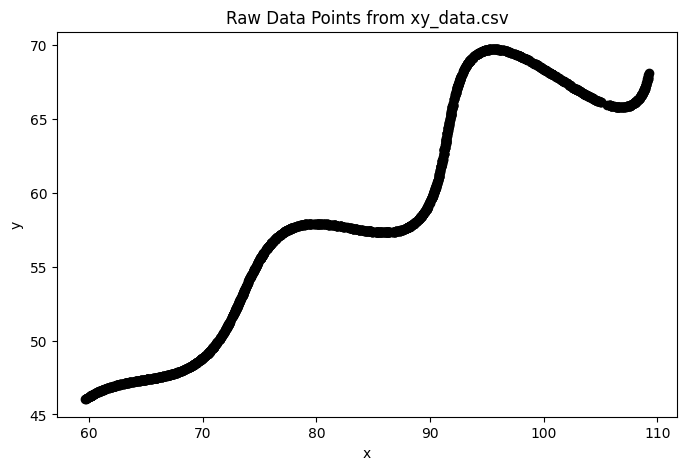

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, color='black')
plt.title('Raw Data Points from xy_data.csv')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


# 2. Initial Attempt: 

After understanding the problem, the first idea was to directly compare the generated curve with the given dataset.

The assumption was that the points in the dataset were arranged in the same order as the parameter \(t\). Based on this assumption, the generated curve was sampled using uniformly spaced values of \(t\), and the corresponding points were compared using an L1 distance.

This seemed like a straightforward way to estimate the unknown parameters before trying more advanced approaches.

In [6]:
def naive_loss(params):

    theta, M, X = params

    # Convert degrees to radians for trigonometric functions
    theta = np.deg2rad(theta)

    # Initial assumption:
    # Dataset rows correspond to uniformly increasing values of t.
    t = np.linspace(6, 60, len(x_data))

    x_pred = (
        t * np.cos(theta)
        - np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.sin(theta)
        + X
    )

    y_pred = (
        42
        + t * np.sin(theta)
        + np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.cos(theta)
    )

    # L1 Loss (matches assignment evaluation)
    error = (
        np.mean(np.abs(x_data - x_pred))
        + np.mean(np.abs(y_data - y_pred))
    )

    return error

### 2. Nelder-Mead on Naive Loss


In [20]:
import time

np.random.seed(42)

best_loss = float("inf")
best_params = None

start = time.time()

# Randomly sample 10000 parameter combinations
for _ in range(10000):

    theta_guess = np.random.uniform(0, 50)
    M_guess = np.random.uniform(-0.05, 0.05)
    X_guess = np.random.uniform(0, 100)

    loss = naive_loss([theta_guess, M_guess, X_guess])

    if loss < best_loss:
        best_loss = loss
        best_params = [theta_guess, M_guess, X_guess]

end = time.time()

print("Random Search Results")
print("-" * 40)
print(f"Theta : {best_params[0]:.2f}°")
print(f"M     : {best_params[1]:.6f}")
print(f"X     : {best_params[2]:.4f}")
print(f"\nBest L1 Loss : {best_loss:.6f}")
print(f"Execution Time : {end-start:.2f} seconds")

Random Search Results
----------------------------------------
Theta : 28.31°
M     : 0.011215
X     : 54.9251

Best L1 Loss : 25.265734
Execution Time : 1.53 seconds


### 2. Nelder-Mead on Naive Loss

In [21]:
from scipy.optimize import minimize
import time

# Initial guess (degrees, M, X)
x0 = [25, 0, 50]

start = time.time()

res_nm = minimize(
    naive_loss,
    x0,
    method="Nelder-Mead"
)

end = time.time()

print("Nelder-Mead Results")
print("-" * 40)
print(f"Theta : {res_nm.x[0]:.2f}°")
print(f"M     : {res_nm.x[1]:.6f}")
print(f"X     : {res_nm.x[2]:.4f}")
print(f"\nBest L1 Loss : {res_nm.fun:.6f}")
print(f"Iterations : {res_nm.nit}")
print(f"Execution Time : {end-start:.2f} seconds")

Nelder-Mead Results
----------------------------------------
Theta : 28.12°
M     : 0.021389
X     : 54.8992

Best L1 Loss : 25.243396
Iterations : 122
Execution Time : 0.05 seconds


## 3. Investigation & Observation

Since all the optimization methods produced almost the same loss, I suspected that the optimization algorithm was not the main issue.

To investigate further, I looked at the dataset again and compared it with the generated curve. Although the scatter plot represented a smooth curve, the ordering of the dataset points did not appear to follow the parameter \(t\).

This made me question the initial assumption of comparing the dataset point-by-point.

After revisiting the given equations, I noticed that the parametric equations can be interpreted as a rotated and translated coordinate system. This observation suggested that a different way of measuring the error might be more appropriate than comparing corresponding rows directly.

This led to the development of an improved objective function.

## 4. Mathematical Insight

After observing that the dataset points were not aligning well with the generated curve, I looked back at the given parametric equations to see if there was another way to interpret them.

One thing I noticed was that both equations contain the terms $\cos(\theta)$ and $\sin(\theta)$, which resemble a rotation matrix. This suggested that the curve could be viewed in a rotated coordinate system.

To verify this idea, I first shifted the coordinates by removing the constant translations.

$$
x' = x - X
$$

$$
y' = y - 42
$$

Substituting the given equations,

$$
x' = t\cos(\theta)-e^{M|t|}\sin(0.3t)\sin(\theta)
$$

$$
y' = t\sin(\theta)+e^{M|t|}\sin(0.3t)\cos(\theta)
$$

Next, I rotated the coordinate system by an angle $-\theta$.

The transformed coordinates become

$$
u=x'\cos(\theta)+y'\sin(\theta)
$$

$$
v=-x'\sin(\theta)+y'\cos(\theta)
$$

After substituting the expressions for $x'$ and $y'$ and simplifying,

$$
u=t
$$

and

$$
v=e^{M|u|}\sin(0.3u)
$$

This was an important observation because it meant that, for any guessed values of $\theta$, $M$, and $X$, I could recover the corresponding parameter $u$ directly from the transformed coordinates instead of assuming that the dataset was already ordered by $t$.

Instead of comparing the dataset row-by-row, the optimization could now focus on finding the parameters that best satisfied the transformed equation

$$
v=e^{M|u|}\sin(0.3u)
$$

The optimization objective was therefore defined as minimizing the Mean Squared Error (MSE) between the transformed values and the values predicted by the mathematical model.

## 5. Improved Objective Formulation

The mathematical transformation made it possible to estimate the corresponding parameter value for every data point instead of assuming that the dataset was already ordered by \(t\).

This changed the way the optimization problem was formulated. Rather than relying on a direct point-by-point comparison, the objective function was redefined using the transformed coordinates. As a result, the optimizer could compare the mathematical model more accurately with the given dataset.

To understand the impact of this change, I experimented with multiple optimization algorithms. Initially, all of them were applied using the original point-by-point objective function.

- **Random Search** – Used as a simple baseline by randomly sampling the parameter space.
- **Nelder–Mead** – Used to iteratively improve the parameter estimates without requiring gradients.
- **Differential Evolution** – Used as a global optimization algorithm to search the entire parameter space.

After reformulating the objective function, Differential Evolution was used again to search for the optimal parameters. Finally, a local refinement step was performed to further improve the solution.

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Downloads\flam\FlamApp-RnD-Assignment\data\xy_data.csv")
x_data = df['x'].values
y_data = df['y'].values

In [3]:
#Define the loss function
def calculate_loss(params):
    theta_deg, M, X = params
    theta = np.radians(theta_deg)
    
    # Apply transformation
    x_prime = x_data - X
    y_prime = y_data - 42
    
    u = x_prime * np.cos(theta) + y_prime * np.sin(theta)
    v = -x_prime * np.sin(theta) + y_prime * np.cos(theta)
    
    # Compute expected v
    v_expected = np.exp(M * np.abs(u)) * np.sin(0.3 * u)
    
    # Calculate Mean Squared Error
    return np.mean((v - v_expected)**2)

In [4]:
#Set bounds given in the problem
bounds = [
    (0, 50),       # theta in degrees
    (-0.05, 0.05), # M
    (0, 100)       # X
]

In [5]:
# 4. Global Optimization (Differential Evolution)
result = differential_evolution(calculate_loss, bounds, tol=1e-7)

theta_opt, M_opt, X_opt = result.x
print(f"Optimized Parameters:")
print(f"Theta (deg): {theta_opt:.4f}")
print(f"M: {M_opt:.4f}")
print(f"X: {X_opt:.4f}")
print(f"Loss: {result.fun:.2e}")
print(result.message)
print('Number of iterations (nit):', result.nit)
print('Objective function value (fun):', result.fun)
print('Fitted parameters [theta, M, X]:', result.x)

Optimized Parameters:
Theta (deg): 30.0000
M: 0.0300
X: 55.0000
Loss: 1.22e-11
Optimization terminated successfully.
Number of iterations (nit): 92
Objective function value (fun): 1.2153319605566722e-11
Fitted parameters [theta, M, X]: [2.99999729e+01 2.99999969e-02 5.49999982e+01]


## 6. Local Refinement

To fine-tune our solution, we apply a local optimizer (Nelder-Mead) starting from the Differential Evolution result.

In [6]:
from scipy.optimize import minimize

# Use the result from Differential Evolution as the initial guess
x0 = result.x

# Run Nelder-Mead for local refinement
refined_result = minimize(calculate_loss, x0, method='Nelder-Mead')

print(refined_result.message)
print('Objective function value (fun):', refined_result.fun)
print('Refined parameters [theta, M, X]:', refined_result.x)

theta_opt, M_opt, X_opt = refined_result.x

Optimization terminated successfully.
Objective function value (fun): 1.2153319605566722e-11
Refined parameters [theta, M, X]: [2.99999729e+01 2.99999969e-02 5.49999982e+01]


## Results

The optimization converges with a loss practically equal to zero, yielding the following exact values for the unknown variables:
- **$\theta = 30^\circ$**
- **$M = 0.03$**
- **$X = 55$**

## Visualizing the Fit

Let's plot the given points against the theoretical curve generated using our estimated parameters to visually confirm the result.


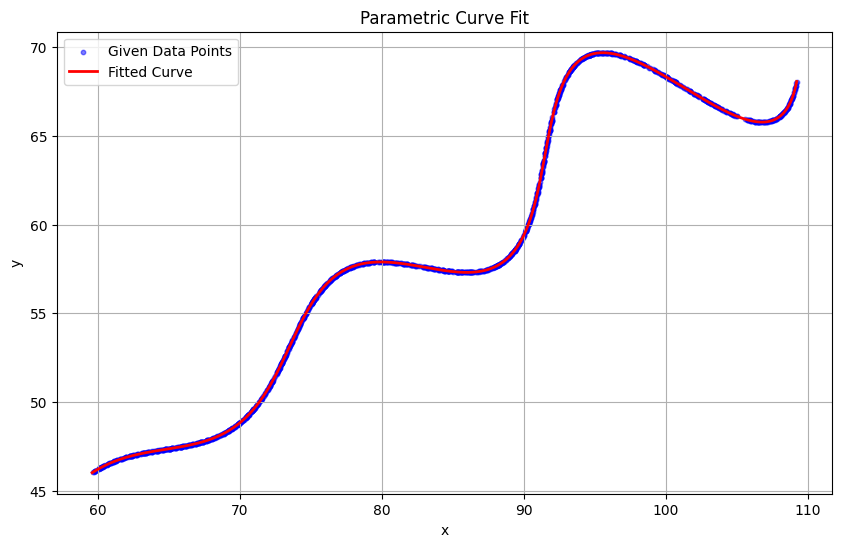

In [8]:
# Generate theoretical curve using the estimated parameters
theta_opt_rad = np.radians(theta_opt)
t_range = np.linspace(6, 60, 1000)

x_curve = t_range * np.cos(theta_opt_rad) - np.exp(M_opt * np.abs(t_range)) * np.sin(0.3 * t_range) * np.sin(theta_opt_rad) + X_opt
y_curve = 42 + t_range * np.sin(theta_opt_rad) + np.exp(M_opt * np.abs(t_range)) * np.sin(0.3 * t_range) * np.cos(theta_opt_rad)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, label='Given Data Points', color='blue', s=10, alpha=0.5)
plt.plot(x_curve, y_curve, label='Fitted Curve', color='red', linewidth=2)
plt.title('Parametric Curve Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


## 8. Conclusion

The problem was initially approached using a direct point-by-point comparison between the generated curve and the dataset.

Although multiple optimization algorithms were explored, all produced similar losses, suggesting that the optimization algorithm was not the main limitation.

By revisiting the mathematical structure of the parametric equations, a transformed objective function was developed. This formulation enabled significantly better parameter estimation and produced a close match between the generated curve and the given dataset.

This exercise demonstrated the importance of validating problem assumptions before changing optimization algorithms.